# 04 - Evaluate Trained MLP on S3DIS Features

This notebook runs quantitative evaluation for the trained translation head on pre-extracted S3DIS features.

It expects feature `.npz` files and trained `.pth` checkpoints to already exist on the shared Google Drive. Choose the feature folder for the target area below.

### 1. Setup Repo & Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

REPO_DIR = '/content/Deep_learning_project'
DRIVE_ROOT = '/content/drive/MyDrive/DL_Project'
EVAL_FEATURES_NAME = 's3dis_area4'
DRIVE_FEATURES_DIR = f'{DRIVE_ROOT}/features/{EVAL_FEATURES_NAME}'
LOCAL_FEATURES_ROOT = '/content/local_features'
LOCAL_FEATURES_DIR = f'{LOCAL_FEATURES_ROOT}/{EVAL_FEATURES_NAME}'
BRANCH = 'dev/eval-demo'

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/Gandata/Deep_learning_project.git {REPO_DIR}


Mounted at /content/drive
Cloning into '/content/Deep_learning_project'...
remote: Enumerating objects: 426, done.
remote: Counting objects: 100% (137/137), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 426 (delta 84), reused 89 (delta 42), pack-reused 289 (from 1)
Receiving objects: 100% (426/426), 40.24 MiB | 39.43 MiB/s, done.
Resolving deltas: 100% (251/251), done.


In [2]:
%cd {REPO_DIR}
!git restore configs/train_mlp_s3dis.yaml notebooks/pyproject.toml
!git fetch origin
!git checkout -B {BRANCH} origin/{BRANCH}
!git pull --no-edit origin {BRANCH}
!git branch --show-current
!git log -1 --oneline

/content/Deep_learning_project
Branch 'dev/eval-demo' set up to track remote branch 'dev/eval-demo' from 'origin'.
Switched to a new branch 'dev/eval-demo'
From https://github.com/Gandata/Deep_learning_project
 * branch            dev/eval-demo -> FETCH_HEAD
Already up to date.
dev/eval-demo
b4ae5e7 (HEAD -> dev/eval-demo, origin/dev/eval-demo) setub eval


### 2. Wire Drive Paths and Copy Features Locally

We keep `data/` and `checkpoints/` on Drive, but copy the selected feature folder to local runtime storage for faster evaluation.

In [10]:
%cd {REPO_DIR}
!rm -f data checkpoints features pretrained
!ln -sf {DRIVE_ROOT}/data ./data
!ln -sf {DRIVE_ROOT}/checkpoints ./checkpoints
!mkdir -p {LOCAL_FEATURES_ROOT}
!rm -rf {LOCAL_FEATURES_DIR}
!cp -r {DRIVE_FEATURES_DIR} {LOCAL_FEATURES_ROOT}/
!ln -sf {LOCAL_FEATURES_ROOT} ./features
!echo Selected feature folder: {EVAL_FEATURES_NAME}
!readlink -f ./features/{EVAL_FEATURES_NAME}
!du -sh {LOCAL_FEATURES_DIR}
!ls -lh ./checkpoints/mlp_s3dis | tail

/content/Deep_learning_project
Selected feature folder: s3dis_area4
/content/local_features/s3dis_area4
18G	/content/local_features/s3dis_area4
-rw------- 1 root root 12M May  6 09:07 epoch_033.pth
-rw------- 1 root root 12M May  6 09:18 epoch_034.pth
-rw------- 1 root root 12M May  6 09:30 epoch_035.pth
-rw------- 1 root root 12M May  6 09:41 epoch_036.pth
-rw------- 1 root root 12M May  6 09:53 epoch_037.pth
-rw------- 1 root root 12M May  6 10:04 epoch_038.pth
-rw------- 1 root root 12M May  6 10:16 epoch_039.pth
-rw------- 1 root root 12M May  6 10:27 epoch_040.pth
-rw------- 1 root root   0 May  6 10:27 history.json
-rw------- 1 root root 12M May  6 10:27 last_model.pth


### 3. Setup Environment & Hugging Face Token

In [4]:
%cd /content/Deep_learning_project/notebooks

from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')
with open('.env', 'w') as f:
    f.write(f'HF_TOKEN={HF_TOKEN}\n')

!uv python install 3.10.12
!uv sync --python 3.10.12

/content/Deep_learning_project/notebooks
Installed Python 3.10.12 in 983ms
 + cpython-3.10.12-linux-x86_64-gnu (python3.10)
Using CPython 3.10.12
Creating virtual environment at: .venv
Resolved 147 packages in 3.14s
Prepared 140 packages in 1m 03s
Installed 141 packages in 289ms
 + addict==2.4.0
 + annotated-doc==0.0.4
 + annotated-types==0.7.0
 + anyio==4.13.0
 + attrs==26.1.0
 + blinker==1.9.0
 + brotli==1.2.0
 + camtools==0.1.8
 + ccimport==0.4.4
 + certifi==2026.4.22
 + charset-normalizer==3.4.7
 + click==8.3.3
 + configargparse==1.7.5
 + contourpy==1.3.2
 + cumm-cu120==0.4.11
 + cycler==0.12.1
 + dash==4.1.0
 + dotenv==0.9.9
 + exceptiongroup==1.3.1
 + fast-pytorch-kmeans==0.2.2
 + fastapi==0.136.1
 + fastjsonschema==2.21.2
 + filelock==3.29.0
 + fire==0.7.1
 + flask==3.1.3
 + fonttools==4.62.1
 + fsspec==2026.4.0
 + ftfy==6.3.1
 + gradio==6.14.0
 + gradio-client==2.5.0
 + groovy==0.1.2
 + h11==0.16.0
 + hf-gradio==0.4.1
 + hf-xet==1.5.0
 + httpcore==1.0.9
 + httpx==0.28.1
 + hugg

In [9]:
from pathlib import Path
import numpy as np

bad = []
for p in sorted(Path("/content/drive/MyDrive/DL_Project/features/s3dis_area4").glob("*.npz")):
    try:
        with np.load(p) as x:
            keys = set(x.files)
        if "features" not in keys or not ({"labels", "label", "segment"} & keys):
            bad.append((p.name, sorted(keys)))
    except Exception as e:
        bad.append((p.name, f"load failed: {e}"))

print("bad files:", len(bad))
for row in bad:
    print(row)


bad files: 0


In [8]:
from pathlib import Path

for name, _ in bad:
    Path("/content/drive/MyDrive/DL_Project/features/s3dis_area4", name).unlink(missing_ok=True)
    print("deleted", name)


deleted Area_4_hallway_1.npz


### 4. Choose a Checkpoint and Run Evaluation

Set `CHECKPOINT_NAME` to the checkpoint you want to evaluate, for example `epoch_040.pth` or `last_model.pth`.

In [11]:
CONFIG_PATH = '/content/Deep_learning_project/configs/train_mlp_s3dis.yaml'
EVAL_BATCH_SIZE = 16384
RESULTS_DIR = '/content/drive/MyDrive/DL_Project/results/evaluation/04'
CHECKPOINT_NAME = 'last_model.pth'
CHECKPOINT_PATH = f'/content/Deep_learning_project/checkpoints/mlp_s3dis/{CHECKPOINT_NAME}'
print('Config:', CONFIG_PATH)
print('Eval batch size:', EVAL_BATCH_SIZE)
print('Results dir:', RESULTS_DIR)
print('Features dir:', f'/content/Deep_learning_project/features/{EVAL_FEATURES_NAME}')
print('Checkpoint:', CHECKPOINT_PATH)

!PYTHONPATH=/content/Deep_learning_project uv run python /content/Deep_learning_project/src/evaluate.py --config {CONFIG_PATH} --features_dir /content/Deep_learning_project/features/{EVAL_FEATURES_NAME} --checkpoint {CHECKPOINT_PATH} --batch_size {EVAL_BATCH_SIZE} --results_dir {RESULTS_DIR}

Config: /content/Deep_learning_project/configs/train_mlp_s3dis.yaml
Eval batch size: 16384
Results dir: /content/drive/MyDrive/DL_Project/results/evaluation/04
Features dir: /content/Deep_learning_project/features/s3dis_area4
Checkpoint: /content/Deep_learning_project/checkpoints/mlp_s3dis/last_model.pth
Using CPython 3.12.13 interpreter at: /usr/bin/python3
Creating virtual environment at: .venv
Installed 99 packages in 304ms
Loading CLIP model ViT-B-32 (openai)...
/content/Deep_learning_project/.venv/lib/python3.12/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
Loaded translation head from /content/Deep_learning_project/checkpoints/mlp_s3dis/last_model.pth
Detected feature dim: 896
Normalize input features: True
Evaluated Area_4_WC_1.npz
Evaluated Area_4_WC_2.npz
Evaluated Area_4_WC_3.npz
Evaluated Area_4_WC_4.npz
Evaluated Area_4_conferenceRoom_1.npz

### 5. Visualize the Saved Evaluation Results

Area metrics file: /content/drive/MyDrive/DL_Project/results/evaluation/04/area_level/s3dis_area4_last_model_metrics.json
Room metrics file: /content/drive/MyDrive/DL_Project/results/evaluation/04/room_level/s3dis_area4_last_model_room_metrics.csv


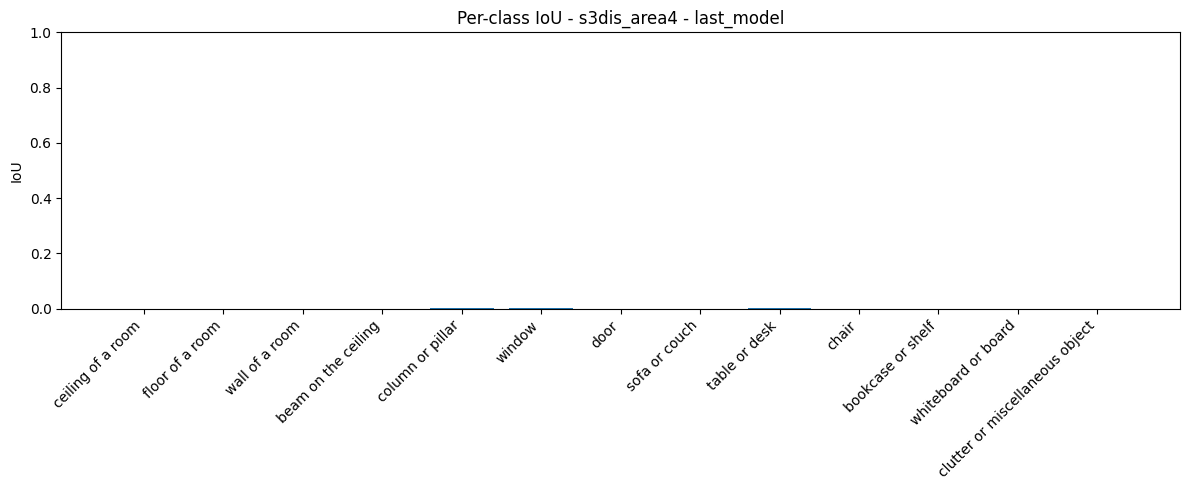

In [12]:
import json
import math
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

AREA_JSON_PATH = Path(RESULTS_DIR) / 'area_level' / f'{EVAL_FEATURES_NAME}_{Path(CHECKPOINT_NAME).stem}_metrics.json'
ROOM_CSV_PATH = Path(RESULTS_DIR) / 'room_level' / f'{EVAL_FEATURES_NAME}_{Path(CHECKPOINT_NAME).stem}_room_metrics.csv'

print('Area metrics file:', AREA_JSON_PATH)
print('Room metrics file:', ROOM_CSV_PATH)

with AREA_JSON_PATH.open('r', encoding='utf-8') as handle:
    area_metrics = json.load(handle)

class_names = area_metrics['class_names']
class_ious = [float('nan') if value is None else float(value) for value in area_metrics['per_class_iou']]

plt.figure(figsize=(12, 5))
plt.bar(range(len(class_names)), class_ious)
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
plt.ylabel('IoU')
plt.ylim(0.0, 1.0)
plt.title(f'Per-class IoU - {EVAL_FEATURES_NAME} - {Path(CHECKPOINT_NAME).stem}')
plt.tight_layout()
plt.show()

,room_file,num_points,oa,miou
0,Area_4_office_4.npz,827508,0.015352,0.006480
1,Area_4_office_21.npz,703551,0.005302,0.002152
2,Area_4_lobby_2.npz,1238087,0.003666,0.001212
3,Area_4_office_20.npz,909214,0.003169,0.001143
4,Area_4_office_9.npz,1069592,0.003029,0.001078
5,Area_4_office_10.npz,1072201,0.002869,0.000922
6,Area_4_conferenceRoom_2.npz,999446,0.001843,0.000628
7,Area_4_office_7.npz,698018,0.001556,0.000576
8,Area_4_office_15.npz,702596,0.001433,0.000458
9,Area_4_lobby_1.npz,2682943,0.000458,0.000269


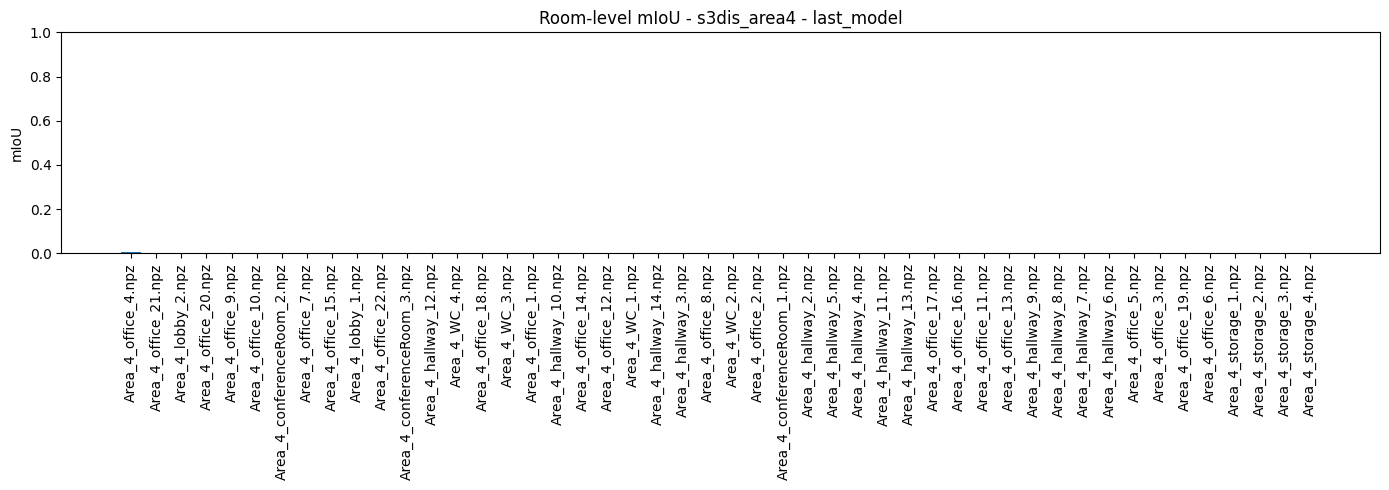

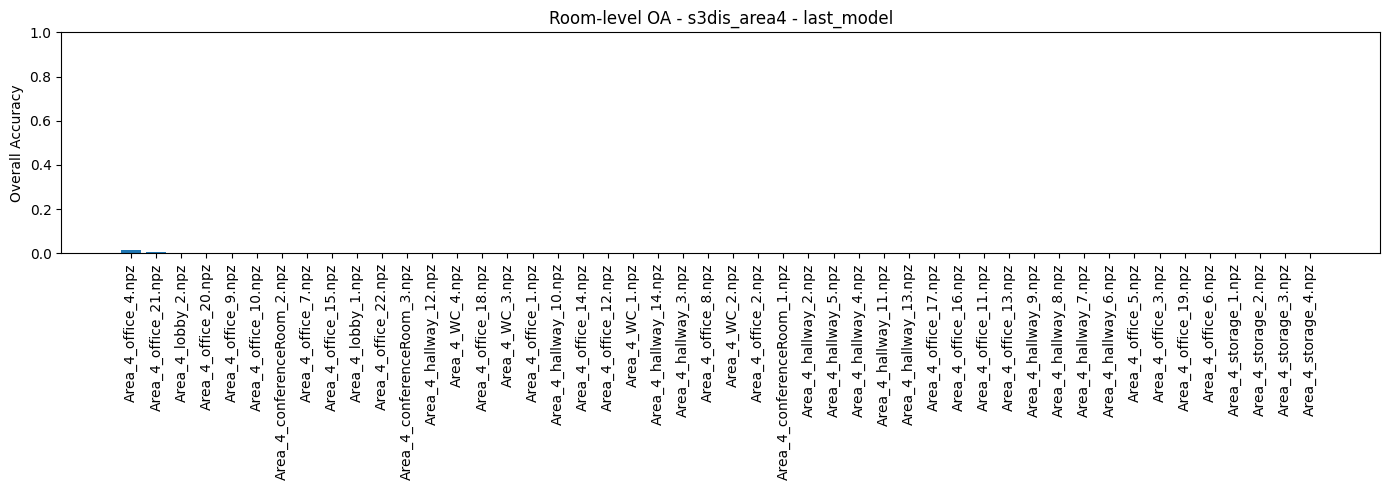

In [13]:
room_df = pd.read_csv(ROOM_CSV_PATH)
room_df = room_df.sort_values('miou', ascending=False).reset_index(drop=True)

display(room_df[['room_file', 'num_points', 'oa', 'miou']].head(10))

plt.figure(figsize=(14, 5))
plt.bar(room_df['room_file'], room_df['miou'])
plt.xticks(rotation=90)
plt.ylabel('mIoU')
plt.ylim(0.0, 1.0)
plt.title(f'Room-level mIoU - {EVAL_FEATURES_NAME} - {Path(CHECKPOINT_NAME).stem}')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.bar(room_df['room_file'], room_df['oa'])
plt.xticks(rotation=90)
plt.ylabel('Overall Accuracy')
plt.ylim(0.0, 1.0)
plt.title(f'Room-level OA - {EVAL_FEATURES_NAME} - {Path(CHECKPOINT_NAME).stem}')
plt.tight_layout()
plt.show()